![jupyter](img/logoItq.png)

**Nombre:** *Adrián Falcones*

**Primer Modulo**

![jupyter](img/logoPy.png)

# Caso Práctico: Neurona de McCulloch y Pitts

Aplicando la MPNeurona un caso práctico real

## Conjunto de datos

Esta es una copia de conjuntos de datos de UCI ML Breast Cancer Winconsin [https://getfireshot.com/pdf_aHR0cHM6Ly9hcmNoaXZlLmljcy51Y2kuZWR1L2RhdGFzZXQvMTcvYnJlYXN0K2NhbmNlcit3aXNjb25zaW4rZGlhZ25vc3RpYw==](https://getfireshot.com/pdf_aHR0cHM6Ly9hcmNoaXZlLmljcy51Y2kuZWR1L2RhdGFzZXQvMTcvYnJlYXN0K2NhbmNlcit3aXNjb25zaW4rZGlhZ25vc3RpYw==)

**Descripcion de la muestra**

Las caracteristicas de entradas de calculan a partir de una imagen digitalizada de un aspirado de aguja fina (FNA) de una masa mamaria. Describen las caracteristicas de los nucleos celulares presentes en la imagen. 

El plano de separacion descrito anteriormente se obtuvo utilizando el metodo de arbol de multiples superficies (MSM-T) "Construccion de un arbol de decision mediante programacion linel"

El programa lineal utilizado para obtener el plano de separacion en el espacio tridimencional es el que describe en (KP Bennet y O. L Mangasarian)

## Lectura de datos

In [6]:
from sklearn.datasets import load_breast_cancer

cancer_mama= load_breast_cancer()
# Separamos Los datos de entra y los datos de salida
X= cancer_mama.data
Y=cancer_mama.target

In [7]:
dir(cancer_mama)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [8]:
print(X)

[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]


## Visualización del conjunto de datos

In [9]:
import pandas as pd

df=pd.DataFrame(X, columns=cancer_mama.feature_names)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [10]:
print(Y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

## División del conjunto de datos

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, Y, stratify = Y)

print("Tamaño de entrenamiento:", len(X_train))
print("Tamaño de pruebas:", len(X_test))

Tamaño de entrenamiento: 426
Tamaño de pruebas: 143


## Implementación de un aMP Neurona más avanzada

In [12]:
# importamos la biblioteca de numpy
import numpy as np
from sklearn.metrics import accuracy_score

class MpNeurona:
    # creamos nuestro constructor
    def _init_(self):
        self.threshold=None

    # Creamos una función par el modelo
    def model(self, x):
        #input: [1,0,1,0][x1,x2,...xn]
        z=sum(x)
        return (z >= self.threshold)
    
    #Creamos la predicción
    def predict(self, X):
        # input:[[1,0,1,0][1,0,1,1]]
        Y=[]
        for x in X:
            result=self.model(x)
            Y.append(result)
        return np.array(Y)

    # función de entrenamiento para e lthreshold
    def fit(self, X, Y):
        accuracy={} # Creamos una variable para guardar los datos de entrada y salida
        # Seleccionamos un threshold entre el # de caracteristicas de entrada
        for th in range(X.shape[1]+1):
            self.threshold = th
            Y_pred = self.predict(X)
            accuracy[th]=accuracy_score(Y_pred, Y)
        
        #Seleccionamos el threshold que mejores resultado proporciona
        self.threshold = max(accuracy, key=accuracy.get)

Los datos de entreeda siguen teniendo porblemas debido a que nuestro conjunto de datos las caracteristicas de entreda reciben valores continuos, sin embargo, la neurona MP solo procesa características de netrada con valores binarios

[0, 0, 1, 1, 1, 0, 0]
Categories (2, int64): [0 < 1]


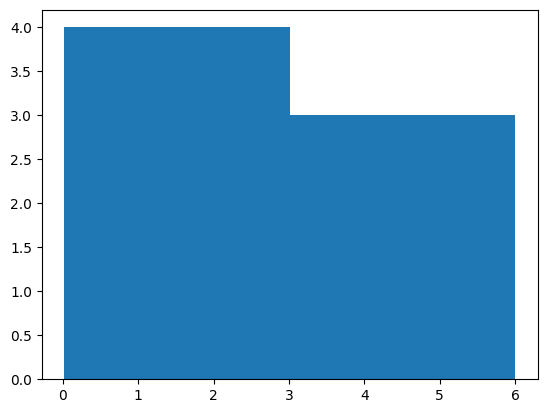

In [13]:
#Para transformar un valor a binario
import matplotlib.pyplot as plt

print(pd.cut([0.04,0.3,4,5,6,0.02,0.6], bins=2, labels=[0,1]))

plt.hist([0.04,0.3,4,5,6,0.02,0.6], bins=2)
plt.show()

In [27]:
# Trasformarmamos las caracteristicas de entrada a un valor binario
X_train_bin = X_train.apply(pd.cut, bins=2, labels=[1,0])
X_test_bin = X_test.apply(pd.cut, bins=2, labels=[1,0])

X_train_bin

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
254,0,1,0,1,0,1,1,1,1,1,...,0,1,0,1,0,1,1,0,1,1
315,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
425,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
388,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
476,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,0,1,0,0,1,1,1,0,1,1,...,0,0,0,1,1,1,1,0,1,1
40,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
281,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1,1
404,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


## Instaciamos el modelo MP

In [15]:
np_neurona = MpNeurona()
#Encontramos el threshold optimo
np_neurona.fit(X_train_bin.to_numpy(), y_train)

## Threshold optimo seleccionado

In [16]:
np_neurona.threshold

28

In [17]:
# Realizamos la predicción par alos datos de prueba
Y_pred=np_neurona.predict(X_test_bin.to_numpy())

In [18]:
Y_pred

array([False, False,  True,  True,  True,  True,  True,  True,  True,
        True, False, False, False, False, False,  True, False,  True,
        True, False,  True, False, False, False,  True,  True,  True,
       False, False, False,  True, False, False, False,  True, False,
        True, False, False,  True, False, False, False,  True,  True,
       False, False, False,  True,  True,  True, False,  True, False,
        True,  True, False,  True,  True, False,  True, False,  True,
        True,  True,  True, False,  True, False,  True,  True, False,
        True,  True,  True, False,  True, False, False,  True, False,
       False, False,  True, False,  True,  True,  True,  True, False,
       False,  True,  True, False, False,  True, False,  True,  True,
       False, False,  True,  True,  True, False,  True, False,  True,
       False, False,  True,  True,  True,  True, False,  True, False,
       False,  True,  True,  True,  True,  True,  True, False, False,
        True,  True,

In [19]:
# Calculaculamos la exactitud de nuestra predicción
accuracy_score(y_test, Y_pred)

0.8671328671328671

## Matriz de confusion

In [20]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, Y_pred)

array([[50,  3],
       [16, 74]])

# Tarea 

De las 30 caracteristicas sacar las 10 mas importantes, para definir si tiene canncer o no, que se pueda ingresar los datos por teclado.

In [21]:
# Top 10 caracteristicas 

top_10_caracteristicas = [
    "worst concave points", 
    "worst perimeter",
    "worst radius",
    "worst area",
    "mean concavity",
    "mean concave points",
    "worst texture", 
    "mean perimeter",
    "mean area",
    "worst concavity"
]

In [22]:
# Cramos un nuevo dataframe para las columnas seleccionadas

df_top10 = df[top_10_caracteristicas]

df_top10

,worst concave points,worst perimeter,worst radius,worst area,mean concavity,mean concave points,worst texture,mean perimeter,mean area,worst concavity
0,0.2654,184.60,25.380,2019.0,0.30010,0.14710,17.33,122.80,1001.0,0.7119
1,0.1860,158.80,24.990,1956.0,0.08690,0.07017,23.41,132.90,1326.0,0.2416
2,0.2430,152.50,23.570,1709.0,0.19740,0.12790,25.53,130.00,1203.0,0.4504
3,0.2575,98.87,14.910,567.7,0.24140,0.10520,26.50,77.58,386.1,0.6869
4,0.1625,152.20,22.540,1575.0,0.19800,0.10430,16.67,135.10,1297.0,0.4000
...,...,...,...,...,...,...,...,...,...,...
564,0.2216,166.10,25.450,2027.0,0.24390,0.13890,26.40,142.00,1479.0,0.4107
565,0.1628,155.00,23.690,1731.0,0.14400,0.09791,38.25,131.20,1261.0,0.3215
566,0.1418,126.70,18.980,1124.0,0.09251,0.05302,34.12,108.30,858.1,0.3403
567,0.2650,184.60,25.740,1821.0,0.35140,0.15200,39.42,140.10,1265.0,0.9387


In [28]:
# Transformamos las caracteristicas a binario

df_test = df_top10.apply(pd.cut, bins=2, labels=[1,0])

df_test

,worst concave points,worst perimeter,worst radius,worst area,mean concavity,mean concave points,worst texture,mean perimeter,mean area,worst concavity
0,0,0,0,1,0,0,1,0,1,0
1,0,0,0,1,1,1,1,0,0,1
2,0,0,0,1,1,0,1,0,1,1
3,0,1,1,1,0,0,1,1,1,0
4,0,0,0,1,1,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...
564,0,0,0,1,0,0,1,0,0,1
565,0,0,0,1,1,1,0,0,1,1
566,1,1,1,1,1,1,0,1,1,1
567,0,0,0,1,0,0,0,0,1,0


# GitHub 

- [https://github.com/ndadri/Cuaderno_python2](https://github.com/ndadri/Cuaderno_python2) 